# **Evolutionary Computing, lab 10 - Report**

**Authors**:
* **Kuba Czech**, 156035
* **Wojciech Nagórka**, 156045

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## **1. Description of the problem** ##

We are given a set of nodes, each defined by its x and y coordinates and an associated cost. The task is to select exactly half of the nodes (rounded up if the number is odd) and construct a Hamiltonian cycle that visits each selected node exactly once and returns to the starting node. The objective is to minimize the total sum of both the path length (computed using rounded Euclidean distances between nodes) and the costs of the selected nodes.

## **2. Pseudocode of implemented algorithms** ##

### **2.1. Data**
**Input:**
- $n$: total number of nodes  
- $nodes[i] = (x_i, y_i, cost_i)$ for $i \in [0, n-1]$: array with all nodes
- $distanceMatrix[i][j] = \text{round}\!\left(\sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}\right)$: euclidean distance between i-th and j-th node
- $TIME\_LIMIT = 8000 ms$: upper limit of running time for ILS algorithm
- $minTemperature = 1.0$: minimal value that temperature can achieve
- $coolingRate = 0.9999$
- $typicalData = 50.0$: expected degradation for delta. Necessary to calculate initial temperature.
- $acceptanceProbability = 0.01$: probability to accept worse solution initially. Necessary to calculate initial temperature.
- $initialTemperature = -typicalDelta/log10(acceptanceRate)$: initial temperature for the algorithm


**Output:**
- $route$: list of nodes forming a closed Hamiltonian cycle  
- $totalCost = \text{distance cost} + \text{node costs}$


### **2.2. Iterative Local Search with Simulated Annealing**

```text
function IterativeLocalSearchWithSimulatedAnnealing():
    route ← getRandomRoute()
    best_route ← SteepestDescent(route)
    current_route ← copy(best_route)
    temperature = initialTemperature

    while total_time < TIME_LIMIT:
        perturbed_route ← applyPerturbation(current_route)
        new_route ← SteepestDescent(perturbed_route)

        f_x = cost(current_route)
        f_y = cost(new_route)
        delta = f_y - f_x
        accept = False

        if delta < 0:
            accept = True
        else:
            probability = e^(delta/temperature)
            if random number < probability:
                accept = True

        if accept:
            current_route = new_route

        if cost(current_route) < cost(best_route):
            best_route = current_route

        temperature = max(temperature * coolingRate, minTemperature)

### **2.3. Function to apply perturbation**

```text
function applyPerturbation(route):
    for k in 1, 2: //apply 2 random nodes exchanges
        i ← random node
        j ← random node larger than i

        reverse nodes between i+1-th and j-th (including)

    for k in 1, 2: // apply 2 random swaps selected-unselected
        i ← random node from the route
        j ← random node from outside of the route

        swap i-th node to j-th node
    return route


## **3. Results of computational experiments** ##

In [17]:
def read_population(file_name: str) -> pd.DataFrame:
    population = pd.read_csv(f"../lab9/evaluation/{file_name}")
    population = population[['cost', 'route']]

    population['route'] = population['route'].apply(lambda x: [int(node) for node in x[1:-1].split('|')])
    return population

def compute_stats(population: str) -> tuple[float, float, float, float]:
    mini = population['cost'].min()
    maxi = population['cost'].max()
    avg = population['cost'].mean()
    sd = round(population['cost'].std(), 2)

    return (mini, maxi, avg, sd)

def produce_stats_table(populations: list[tuple[str, pd.DataFrame]]) -> pd.DataFrame:
    to_merge = []
    for pop_name, pop in populations:
        to_merge.append([pop_name, *compute_stats(pop)])

    return pd.DataFrame(to_merge, columns=['method_name', 'min', 'avg', 'max', 'sd'])

def import_and_produce_stats_table(file_names: list[str]) -> list[str, pd.DataFrame]:
    all_populations = []
    for name in file_names:
        method_name = "EA" + name.split('.')[0][4:]
        curr_pop = read_population(name)

        all_populations.append([method_name, curr_pop])
    return produce_stats_table(all_populations)

In [49]:
def plot_histogram(instance_name, nr_of_iterations):
    plt.figure(figsize=(10, 6))
    plt.hist(nr_of_iterations, bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of Number of Iterations until Convergence for {instance_name}')
    plt.xlabel('Number of Iterations')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

def plot_barchart(instance_name, nr_of_iterations):
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, len(nr_of_iterations)+1), nr_of_iterations, color='skyblue')
    
    plt.xlabel('Run Index')
    plt.ylabel('Number of Iterations of Algorithm')
    plt.title(f'Barchart of Number of Iterations before algorithm was stopped for {instance_name}')
    lower_limit = (min(nr_of_iterations) - 100)// 50 * 50
    upper_limit = (max(nr_of_iterations) + 50)// 50 * 50
    plt.ylim(lower_limit, upper_limit)

    plt.xticks(range(1, len(nr_of_iterations)+1))
    plt.grid(axis='y')
    plt.show()

### **3.1. Instance A** 

#### **3.1.1. Results**

In [45]:
stats = pd.read_csv('evaluation/TSPA_stats.csv')

stats_heuristic = pd.concat([
    pd.read_csv('../lab1/evaluation/TSPA_stats.csv'),
    pd.read_csv('../lab2/evaluation/TSPA_stats.csv')
    ], ignore_index=True)

stats_local = pd.concat([
    pd.read_csv('../lab3/evaluation/TSPA_local_stats.csv'),
    pd.read_csv('../lab4/evaluation/TSPA_stats.csv'),
    pd.read_csv('../lab5/evaluation/TSPA_stats.csv')
    ], ignore_index=True)

stats_LS_variants = pd.concat([
    pd.read_csv('../lab6/evaluation/TSPA_stats.csv'), # ILS + MSLS
    pd.read_csv('../lab7/evaluation/TSPA_stats.csv'), # LNS
    ], ignore_index=True)

stats_HEA = import_and_produce_stats_table(["TSPA_Op1_WithLS.csv", "TSPA_Op1_NoLS.csv", "TSPA_Op2_WithLS.csv", "TSPA_Op2_NoLS.csv"])

stats

,method_name,min,max,avg,sd
0,ILS_with_SA,69104.0,69567.0,69246.7,129.53


#### **3.1.2. Comparison with ILS, MSLS, LNS and Hybrid Evoultionary Algorithm**

In [46]:
pd.concat([stats_LS_variants, stats_HEA, stats]).reset_index(drop=True)

,method_name,min,max,avg,sd
0,MSLS,70585.0,71825.00,71364.65,298.91
1,ILS,69152.0,69895.00,69471.40,229.85
2,LNSWithLS,69450.0,70425.00,69936.50,271.51
3,LNSWithoutLS,69492.0,70880.00,70211.55,398.62
4,EA_Op1_WithLS,69136.0,69366.25,69785.00,147.56
5,EA_Op1_NoLS,71477.0,72016.40,72785.00,372.71
6,EA_Op2_WithLS,69349.0,69552.25,69902.00,157.91
7,EA_Op2_NoLS,69704.0,70384.55,70983.00,327.16
8,ILS_with_SA,69104.0,69567.00,69246.70,129.53


#### **3.1.3. Number of iterations** ####
##### **3.1.3.1. Tabular results** 

In [47]:
nr_of_iterations_a = np.array(pd.read_csv('evaluation/TSPA_number_of_iterations.csv', header=None).values).flatten()

nr_of_iterations_summary = pd.DataFrame([
    {
        'instance': 'TSPA',
        'min': np.min(nr_of_iterations_a),
        'max': np.max(nr_of_iterations_a),
        'avg': np.mean(nr_of_iterations_a)
    }
])
nr_of_iterations_summary

,instance,min,max,avg
0,TSPA,4173,4469,4320.6


##### **3.1.3.2. Histogram**

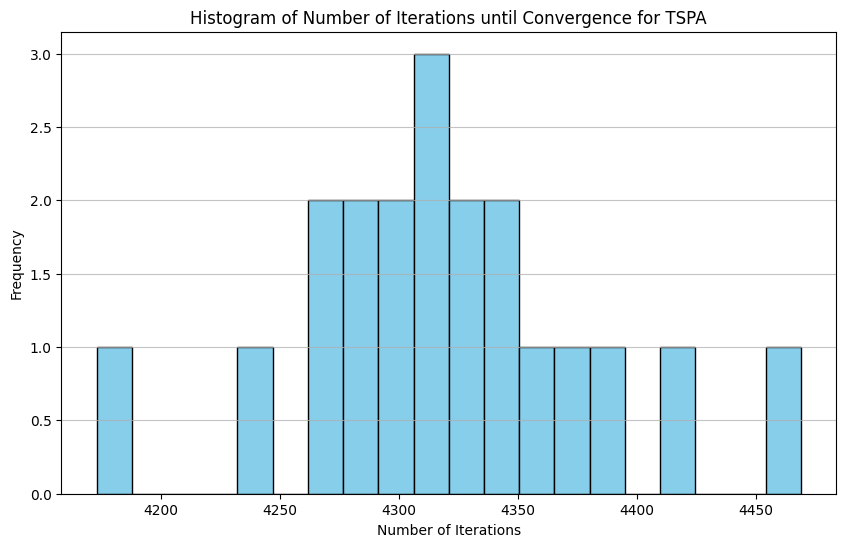

In [50]:
plot_histogram('TSPA', nr_of_iterations_a)

##### **3.1.3.3. Barchart**

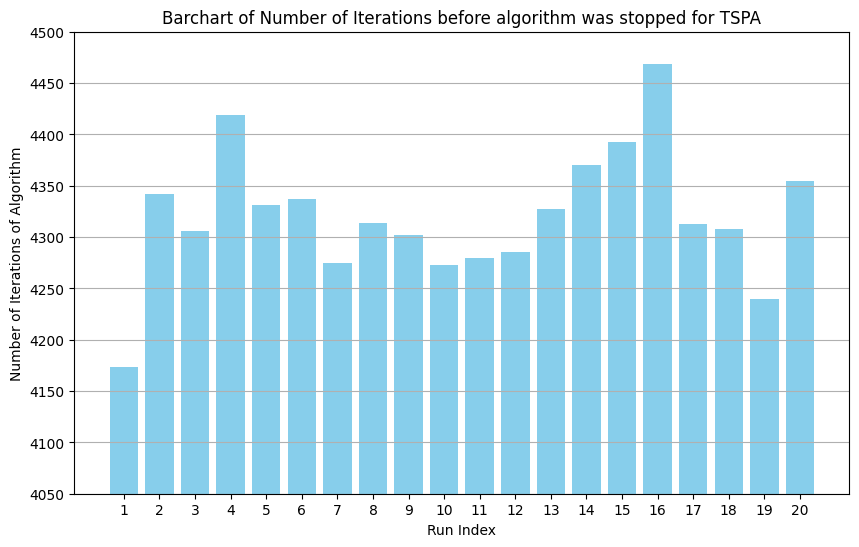

In [51]:
plot_barchart('TSPA', nr_of_iterations_a)

### **3.2. Instance B** 

#### **3.2.1. Results**

In [20]:
stats = pd.read_csv('evaluation/TSPB_stats.csv')

stats_heuristic = pd.concat([
    pd.read_csv('../lab1/evaluation/TSPB_stats.csv'),
    pd.read_csv('../lab2/evaluation/TSPB_stats.csv')
    ], ignore_index=True)

stats_local = pd.concat([
    pd.read_csv('../lab3/evaluation/TSPB_local_stats.csv'),
    pd.read_csv('../lab4/evaluation/TSPB_stats.csv'),
    pd.read_csv('../lab5/evaluation/TSPB_stats.csv')
    ], ignore_index=True)

stats_LS_variants = pd.concat([
    pd.read_csv('../lab6/evaluation/TSPB_stats.csv'), # ILS + MSLS
    pd.read_csv('../lab7/evaluation/TSPB_stats.csv'), # LNS
    ], ignore_index=True)

stats_HEA = import_and_produce_stats_table(["TSPB_Op1_WithLS.csv", "TSPB_Op1_NoLS.csv", "TSPB_Op2_WithLS.csv", "TSPB_Op2_NoLS.csv"])

stats

,method_name,min,max,avg,sd
0,ILS_with_SA,43448.0,44232.0,43801.2,255.26


#### **3.2.2. Comparison with ILS, MSLS, LNS and Hybrid Evoultionary Algorithm**

In [22]:
pd.concat([stats_LS_variants, stats_HEA, stats]).reset_index(drop=True)

,method_name,min,max,avg,sd
0,MSLS,44790.0,46322.00,45583.15,388.16
1,ILS,43477.0,44552.00,43859.30,316.47
2,LNSWithLS,43652.0,45799.00,44211.60,493.60
3,LNSWithoutLS,43671.0,46604.00,44906.85,829.88
4,EA_Op1_WithLS,43473.0,43706.75,43943.00,128.19
5,EA_Op1_NoLS,45925.0,46573.10,47182.00,404.03
6,EA_Op2_WithLS,43532.0,43908.30,44599.00,259.97
7,EA_Op2_NoLS,43785.0,44441.30,45203.00,384.97
8,ILS_with_SA,43448.0,44232.00,43801.20,255.26


#### **3.2.3. Number of iterations** ####
##### **3.2.3.1. Tabular results** 

In [54]:
nr_of_iterations_b = np.array(pd.read_csv('evaluation/TSPB_number_of_iterations.csv', header=None).values).flatten()

nr_of_iterations_summary = pd.DataFrame([
    {
        'instance': 'TSPB',
        'min': np.min(nr_of_iterations_b),
        'max': np.max(nr_of_iterations_b),
        'avg': np.mean(nr_of_iterations_b)
    }
])
nr_of_iterations_summary

,instance,min,max,avg
0,TSPB,4133,4327,4259.8


##### **3.2.3.2. Histogram**

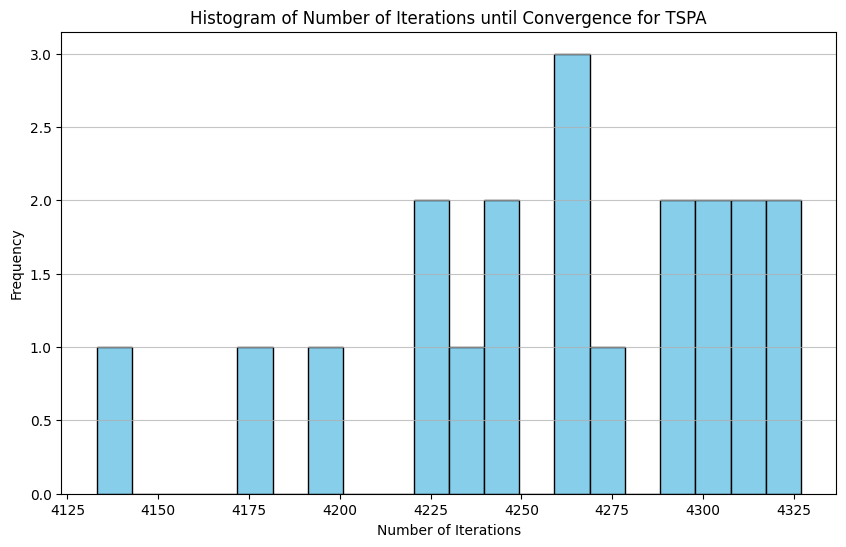

In [55]:
plot_histogram('TSPA', nr_of_iterations_b)

##### **3.2.3.3. Barchart**

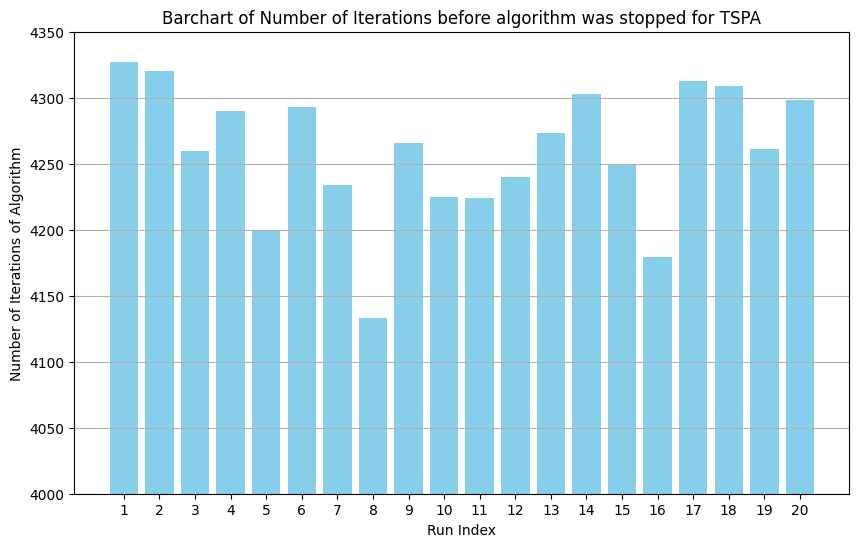

In [56]:
plot_barchart('TSPA', nr_of_iterations_b)

## **4. 2D Visualization** ##

### **Reading TSP A and TSP B instances** ##

In [23]:
tsp_a = pd.read_csv('../data/TSPA.csv', sep=';', header=None)
tsp_a.columns = ['x', 'y', 'cost']

tsp_b = pd.read_csv('../data/TSPB.csv', sep=';', header=None)
tsp_b.columns = ['x', 'y', 'cost']

### **Reading files with best solutions** ##

In [34]:
tsp_a_ils_with_sa = pd.read_csv('evaluation/results/TSPA_best_solution.csv', header=None).values.flatten()
tsp_b_ils_with_sa = pd.read_csv('evaluation/results/TSPB_best_solution.csv', header=None).values.flatten()

In [36]:
def plot_tsp(tsp, solution, title):
    unused_nodes = np.array(set(tsp.index).difference(solution))
    X = tsp['x'].loc[solution].values
    Y = tsp['y'].loc[solution].values
    costs = tsp['cost'].loc[solution].values

    X_unused = tsp['x'].loc[unused_nodes].values
    Y_unused = tsp['y'].loc[unused_nodes].values
    costs_unused = tsp['cost'].loc[unused_nodes].values

    plt.figure(figsize=(15, 9))
    plt.scatter(X, Y, s=costs, color='red', alpha=0.4, label='Data points')
    plt.scatter(X_unused, Y_unused, s=costs_unused, color="grey", alpha=0.4, label="Unused nodes")
    plt.scatter(X, Y, color='blue')
    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')

    plt.plot(X, Y, color='blue', linestyle='-', linewidth=2, label='Connecting line')

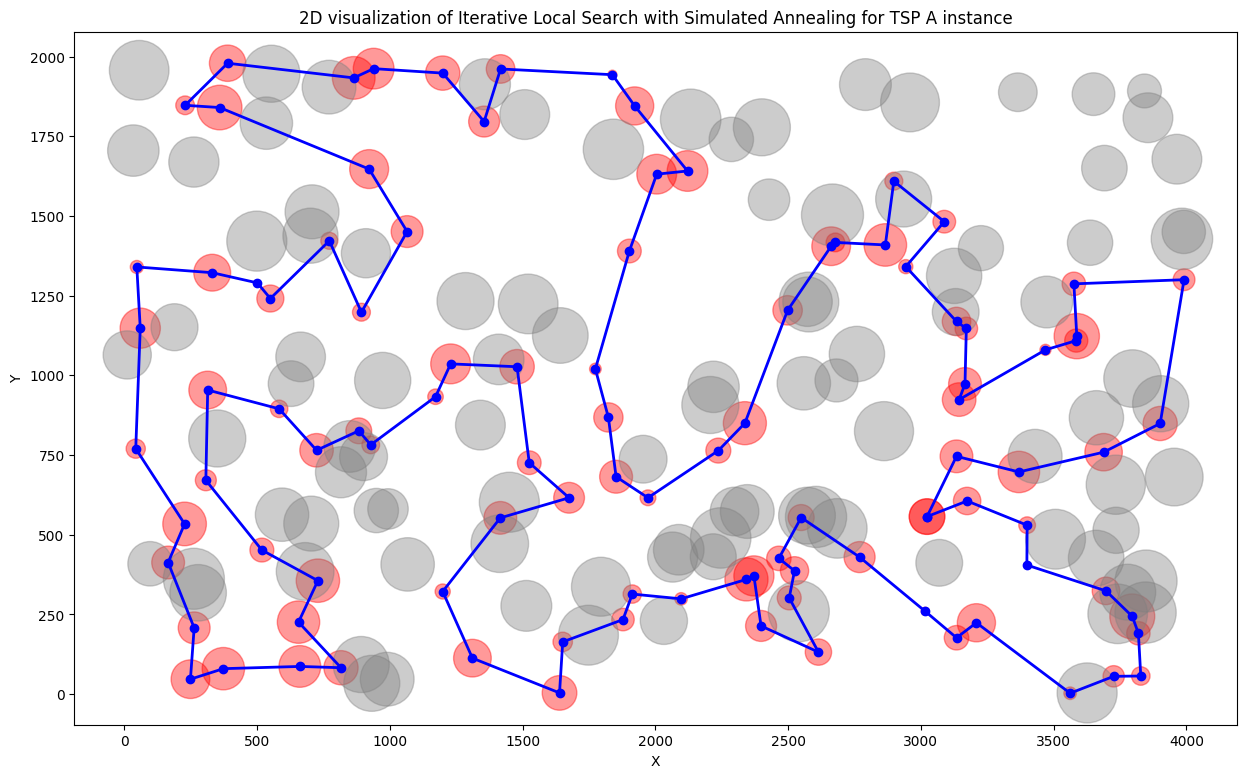

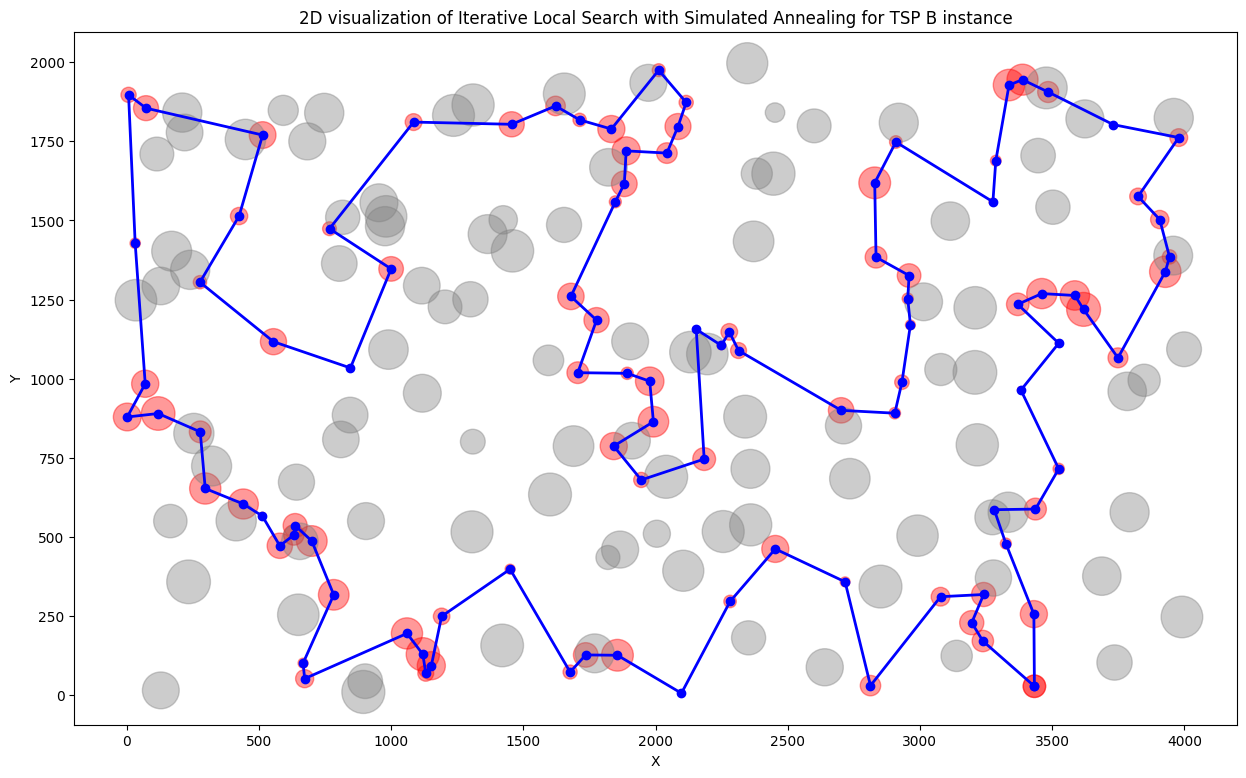

In [57]:
instances = [
    (tsp_a, tsp_a_ils_with_sa, '2D visualization of Iterative Local Search with Simulated Annealing for TSP A instance'),
    (tsp_b, tsp_b_ils_with_sa, '2D visualization of Iterative Local Search with Simulated Annealing for TSP B instance')
]
for i in instances:
    plot_tsp(*i)

## **5. Display of the results** ##

### **5.1. TSP A instance** ###

In [38]:
tsp_a_ils_with_sa

array([129,  92, 145,  78,  31,  56, 113, 175, 171,  16,  25,  44, 120,
         2, 152,  97,   1, 101,  75,  86,  26, 100,  53, 180, 154, 135,
        70, 127, 123, 162, 133, 151,  51, 118,  59,  65, 116,  43,  42,
       181, 160, 184,  35,  84, 112,   4, 190,  10, 177,  54,  48,  34,
       146,  22, 159, 193,  41, 139, 115,  46,  68,  69,  18, 108, 140,
        93, 117,   0, 143, 183,  89, 186,  23, 137, 176,  80,  79,  63,
        94, 124, 148,   9,  62, 102, 144,  14,  49, 178, 106,  52,  55,
       185,  40, 119, 165,  90,  81, 196, 179,  57, 129])

### **5.2. TSP B instance** ###

In [39]:
tsp_b_ils_with_sa

array([137, 127,  89, 103, 163, 187, 153,  81,  77, 141,  91,  61,  36,
       177,   5,  78, 175, 142,  45,  80, 190, 136,  73,  54,  31, 193,
       117, 198, 156,   1,  16,  27,  38,  63,  40, 107, 133, 122, 135,
       131, 121,  51,  90, 147,   6, 188, 169, 132,  70,   3,  15, 145,
        13, 195, 168, 139,  11, 138,  33, 160, 144, 104,   8, 111,  29,
         0, 109,  35, 143, 106, 124,  62,  18,  55,  34, 170, 152, 183,
       140,   4, 149,  28,  20,  60, 148,  47,  94,  66, 179,  22,  99,
       130,  95, 185,  86, 166, 194, 176, 113, 114, 137])

## **6. Usage of solution checker**

Solution checker was used for all computed above solutions and value of objective functions are correct.

## **7. Link to the source code** ##

https://github.com/WojtekNagorka/Evolutionary-computation/tree/main/lab10

## **8. Conclusions**

1. The addition of temperature to ILS improves the solution quality.
2. Implementation of ILS with Simulated Annealing combines the advantages of both, thus improving the results.
3. Best result produced by our implementation beat all previous results.